# DSE 230: Programming Assignment 4 - K-Means Cluster Analysis with Scikit-learn and Dask
---
#### Tasks:
 - Explore parallelism with scikit-learn for k-means clustering
 - Explore parallelism with dask for k-means clustering

#### Submission on Gradescope:
* You need to submit the following file under "PA4". **(please keep the file name as shown below in bold)**:
    * The current notebook - **PA4_Starter.ipynb** - with all cells executed
      
#### IMPORTANT submission guidelines enforced by autograder. Please read carefully:
  * Make sure that all the cells in this notebook are executed and that the outputs are present in the expected cells before submission
  * Some cells are marked **DO NOT DELETE**. These cells cannot be deleted and the output of these cells will be used for autograding
  * You can add additional cells, but the **Expected Output** for each of the tasks MUST be the output of the cells marked as such
  * DO NOT show anything other than the *exact* expected output. **Do not include any sentences/words describing the output**. This is strictly enforced by the autograder which checks for an *exact* match of the expected output. For example, if you are expected to show the PySpark version:
      * '10.9.8' - <span style="color:#093">CORRECT</span>
      * 'The PySpark version is 10.9.8' - <span style="color:#FF0000">INCORRECT</span>
  * You can add cells for showing debugging information anywhere, but do not show anything else in **Expected Output** cells other than the expected output for the task
  * Guidelines for displaying contents of a dataframe in the notebook - Enforced by the autograder:
    * **Do NOT use the print() function to show your output unless explicitly stated. Instead, place your intended output as the last line of the cell**
    * Use DataFrame.show() with appropriate arguments for n and truncate (only if explicitly stated), to display the entire cell contents of a dataframe in the notebook.
    * **Refrain from using DataFrame.head(n)** as it displays multi-column dataframes in an unintuitive way. This will be enforced by the autograder.
    * Increase Docker container memory to 8GB if required using either Docker Desktop or changing launch script (docker run command at the end).


---

Remember: When in doubt, read the documentation first. It's always helpful to search for the class that you're trying to work with, e.g. dask.dataframe.DataFrame.

scikit-learn Documentation: https://scikit-learn.org/stable/index.html

Dask Documentation:  https://docs.dask.org/en/stable/

## Setup

In [1]:
# ALL IMPORTS HERE
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


## 1. Parallelism with Scikit-Learn - 4 points
---

### 1.1 Load Data - 0.5 points

#### Tasks:

1. Load the "minute_weather.csv" into the Pandas dataframe
2. Drop null values i.e drop all the rows where a null value is present in at least one column
3. Drop the four columns ["rowID", "hpwren_timestamp", "rain_accumulation", "rain_duration"] from the dataframe since they are not useful features for the clustering task.

In [2]:
df = pd.read_csv('/home/minute_weather.csv')
df = df.dropna()
df = df.drop(columns=['rowID', 'hpwren_timestamp', 'rain_accumulation', 'rain_duration'])

#### **Expected output**: Column names of the resulting dataframe in a pandas.Index sequence

Useful function/attribute - [pandas.DataFrame.columns](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.columns.html)

In [3]:
df.columns

Index(['air_pressure', 'air_temp', 'avg_wind_direction', 'avg_wind_speed',
       'max_wind_direction', 'max_wind_speed', 'min_wind_direction',
       'min_wind_speed', 'relative_humidity'],
      dtype='object')

### 1.2 Split the data to training and testing dataset - 0.5 points

#### Task:
Perform train and test split with 70% of the original dataset being the training dataset and 30% of the original dataset being the testing dataset.

**IMPORTANT** - Pass `random_state=seed` to `train_test_split` for reproducing results

#### Expected output:
1. Number of samples from both train and test dataset
2. Summary statistics of training dataset. Use `DataFrame.describe()`

In [5]:
seed = 230 # Pass this parameter as `random_state=seed` to train_test_split
X_train, X_test = train_test_split(df, test_size=0.3, random_state=seed)

#### **Expected output**: Number of samples from both train and test dataset in a python tuple - (n_train_samples, n_test_samples)

In [6]:
(len(X_train), len(X_test))

(1110776, 476047)

#### **Expected output**: Summary statistics of training dataset

In [8]:
X_train.describe()

,air_pressure,air_temp,avg_wind_direction,avg_wind_speed,max_wind_direction,max_wind_speed,min_wind_direction,min_wind_speed,relative_humidity
count,1.110776e+06,1.110776e+06,1.110776e+06,1.110776e+06,1.110776e+06,1.110776e+06,1.110776e+06,1.110776e+06,1.110776e+06
mean,9.168329e+02,6.185577e+01,1.618711e+02,2.775055e+00,1.633149e+02,3.400906e+00,1.667906e+02,2.133691e+00,4.757584e+01
std,3.053017e+00,1.183519e+01,9.522479e+01,2.060536e+00,9.235597e+01,2.423461e+00,9.750163e+01,1.744804e+00,2.620532e+01
min,9.050000e+02,3.164000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,7.000000e-01
25%,9.148000e+02,5.270000e+01,6.200000e+01,1.300000e+00,6.800000e+01,1.600000e+00,7.600000e+01,8.000000e-01,2.470000e+01
50%,9.167000e+02,6.224000e+01,1.820000e+02,2.200000e+00,1.870000e+02,2.800000e+00,1.800000e+02,1.600000e+00,4.470000e+01
75%,9.187000e+02,7.088000e+01,2.170000e+02,3.800000e+00,2.230000e+02,4.600000e+00,2.120000e+02,3.000000e+00,6.800000e+01
max,9.295000e+02,9.950000e+01,3.590000e+02,3.170000e+01,3.590000e+02,3.600000e+01,3.590000e+02,3.120000e+01,9.300000e+01


### 1.3 Data Normalization - 1 point

#### Task:
Perform feature normalization on both the train dataset and the test dataset using StandardScaler from sklearn library.

**IMPORTANT** - Use only the training data to scale test data

#### Expected output:
Mean and standard deviation along the feature columns of both the scaled train data and the scaled test dataset

**HINT** - your output of the mean and std should be a 1D numpy array of shape (number of features,)

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### **Expected output**: Mean along the feature columns of scaled train data

In [10]:
X_train_scaled.mean(axis=0)

array([-6.52214028e-15,  2.63804605e-17,  4.43171267e-17, -4.45218248e-18,
       -8.81736828e-17, -1.02656069e-16, -1.70411122e-17, -2.17491673e-17,
        5.81342447e-17])

#### **Expected output**: Standard deviation along the feature columns of scaled train data

In [11]:
X_train_scaled.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

#### **Expected output**: Mean along the feature columns of scaled test data

In [12]:
X_test_scaled.mean(axis=0)

array([-0.00292002, -0.00014293,  0.00330035, -0.00126423,  0.00318349,
       -0.00150067,  0.00122555, -0.00107029,  0.00264351])

#### **Expected output**: Standard deviation along the feature columns of scaled test data

In [13]:
X_test_scaled.std(axis=0)

array([0.99835022, 0.99930403, 0.99941347, 1.00035891, 1.0004042 ,
       0.99959565, 0.99867044, 1.00103404, 1.00038569])

### 1.4 KMeans Clustering model with sklearn - 0.5 points

**NOTE** - From scikit-learn v0.23, all cores are used by default when building a KMeans clustering model. If you want to use a specific number of cores, you can set the `OMP_NUM_THREADS` environment variable

#### Task:

Use the normalized training dataset to fit a K-means model with **8** clusters. **IMPORTANT** - Pass `random_state=seed` to `KMeans` for reproducing results

#### Expected output:
Cluster centers found by the model

In [15]:
kmeans = KMeans(n_clusters=8, random_state=seed)
kmeans.fit(X_train_scaled)
seed = 230 # Pass this parameter as `random_state=seed` to KMeans


#### **Expected output**: Cluster centers, an ndarray of shape (n_clusters, n_features)

In [16]:
kmeans.cluster_centers_

array([[-1.03908922, -0.88476055,  0.42566278,  1.67656754,  0.51680892,
         1.61374037,  0.25292902,  1.69957548,  0.96925377],
       [-0.27891155,  0.21006216, -1.04316954, -0.66328165, -0.91571774,
        -0.69016527, -1.23024442, -0.59394214,  0.0265158 ],
       [ 1.17245752,  0.04555265, -1.15533869, -0.07995442, -1.04999179,
        -0.07687145, -1.32362012, -0.07499923, -0.88556553],
       [ 0.13508845,  0.70659535,  0.92252792, -0.67057141,  0.60642432,
        -0.64578487,  0.63568006, -0.67907299, -0.61841546],
       [-0.21277359, -1.03126375,  0.56274195, -0.33444333,  0.54603875,
        -0.31479577,  0.31640584, -0.35366614,  1.21351386],
       [ 1.17670099, -0.26669086, -1.14839463,  2.10856993, -1.05378588,
         2.20664911, -1.29603215,  1.89181275, -1.1085992 ],
       [-0.21382615,  0.5624567 ,  0.40315238,  0.49955738,  0.47350683,
         0.44322436,  0.23820032,  0.54280904, -0.18826732],
       [ 0.29653409,  0.27108614, -1.52388511, -0.61020981, -1

### 1.5 Evaluate KMeans clustering model with sklearn - 1.5 points
- Output the inertia_ variable of the model
- Output the within-cluster sum of squares (WSSE) on the train and test dataset. Check [`KMeans.score`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans.score). WSSE is the negative of the return value of `KMeans.score`

Check documentations on KMeans at https://scikit-learn.org/stable/modules/clustering.html

#### **Expected output**: Inertia of the KMeans model

In [17]:
kmeans.inertia_

3686661.6955809076

#### **Expected output**: WSSE on the train dataset

In [18]:
-kmeans.score(X_train_scaled)

3686661.6955809076

#### **Expected output**: WSSE on the test dataset

In [19]:
-kmeans.score(X_test_scaled)

1580930.2194285924

### 1.6 Create Parallel Coordinate Plot - 0.25 points

#### Task:
- Create a parallel coordinate plot to show the feature values corresponding to the cluster centers for all clusters.

Data samples were standardized to have 0-mean and 1-standard-deviation before k-means was applied, so values of cluster centers can be interpreted as standard deviations from the mean.

Weather patterns represented by each of the cluster centers are determined by the value of the dimension corresponding to the feature being above or below the mean value of the feature in the training data. For example, cluster centers that have the value of their 9th dimension (which corresponds to relative_humidity) being below the mean represent dry weather patterns.

The code to create the plot is provided to you. Just call the parallel_plot function with the appropriate arguments to display the plot in the notebook.

In [20]:
# DO NOT MODIFY

from itertools import cycle, islice
import matplotlib.pyplot as plt
def parallel_plot(df_columns, num_clusters, model):
    """
    df_columns: Names of features (Columns of Pandas DataFrame) - Same as output of Q1.1
    num_clusters: Number of clusters, k, used to fit the sklearn K-means model
    model: sklearn K-means model
    """
    colNames = list(df_columns)
    colNames.append('prediction')
    centers = model.cluster_centers_
    
    # Zip with a column called 'prediction' (index)
    Z = [np.append(A, index) for index, A in enumerate(centers)]
    
    # Convert to pandas for plotting
    data = pd.DataFrame(Z, columns=colNames)
    data['prediction'] = data['prediction'].astype(int)

    ylim=[-3,+3]
    figsize=(20,8)
    my_colors = list(islice(cycle(['r', 'y', 'g', 'b', 'c', 'k', 'm']), None, num_clusters))
    plt.figure(figsize=figsize).gca().axes.set_ylim(ylim)
    labels = data.drop('prediction',axis=1).keys().tolist()
    for i in range(len(data)):
        values = data.iloc[i].tolist()
        plt.plot(labels, values[:-1], marker="o", color=my_colors[int(values[-1])])
    plt.legend(data['prediction'].tolist())
    plt.grid(True)
    plt.title("Parallel Plot of Cluster Centers")
    return

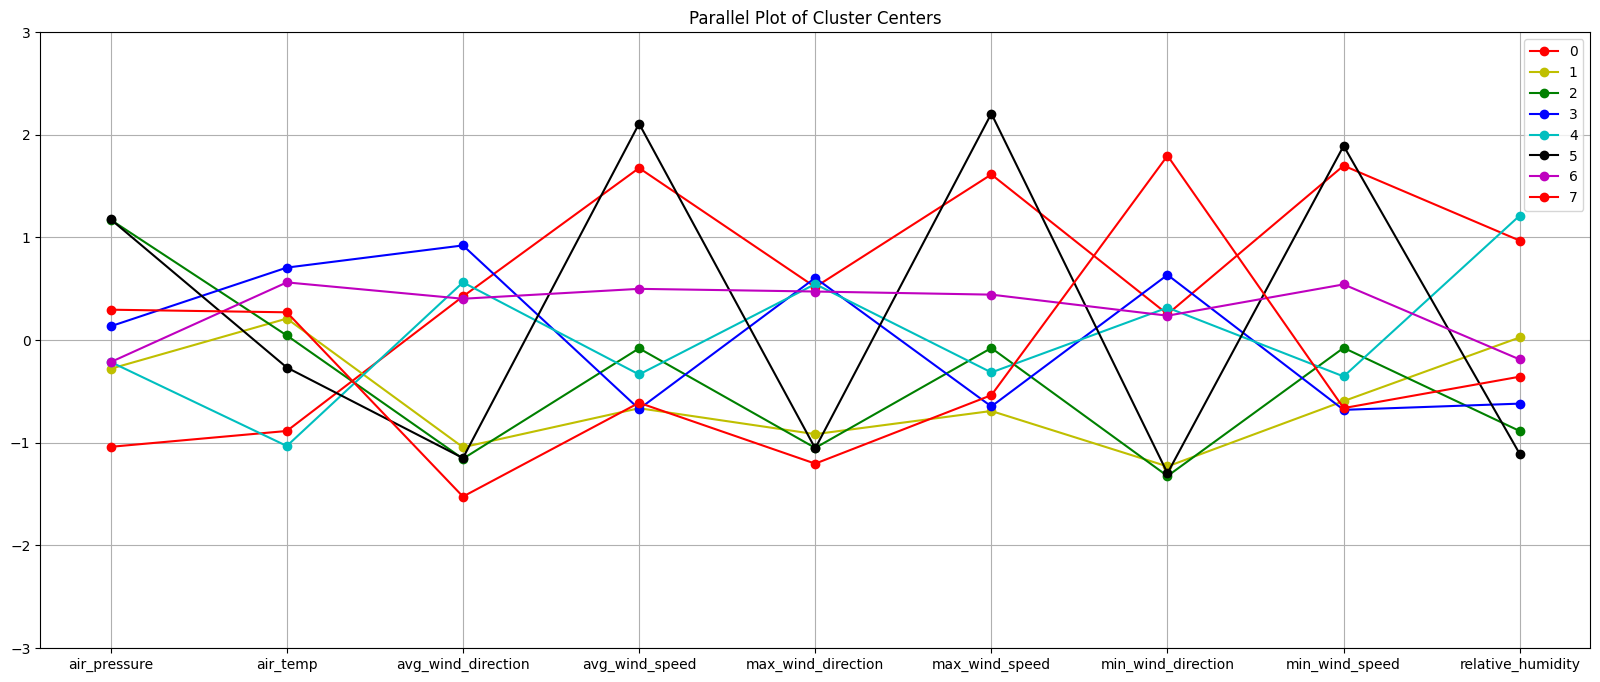

In [21]:
parallel_plot(df.columns, 8, kmeans)

---
## 2. Parallelism with Dask - 6 points

### 2.1 Setup the Dask distributed client - 0.5 points

#### Task:
Create a Dask distributed client with 2 worker nodes and 2 threads per worker, same as the Dask UI Demo. Set arguments for `n_workers`, `threads_per_worker`, `processes`, `memory_limit`, and (optionally) `silence_logs` to surpress dask client warnings.

#### Expected output
Output the Dask client information

In [22]:
# ALL IMPORTS HERE
import dask
from dask.distributed import Client
import dask.dataframe as dd
from dask_ml.model_selection import train_test_split
from dask_ml.preprocessing import StandardScaler
from dask_ml import cluster
import logging

In [23]:
# YOUR CODE HERE TO CREATE THE CLIENT
#PASS ARGUMENT silence_logs = logging.ERROR TO THE CLIENT TO SURPRESS DASK WARNINGS
client = Client(n_workers=2, threads_per_worker=2, processes=False, memory_limit='2GB', silence_logs=logging.ERROR)

In [24]:
# RUN THIS CELL TO GET CLIENT INFO
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://172.17.0.2:8787/status,
Dashboard: http://172.17.0.2:8787/status,Workers: 2
Total threads: 4,Total memory: 3.73 GiB
Status: running,Using processes: False
Comm: inproc://172.17.0.2/583/1,Workers: 2
Dashboard: http://172.17.0.2:8787/status,Total threads: 4
Started: Just now,Total memory: 3.73 GiB
Comm: inproc://172.17.0.2/583/4,Total threads: 2
Dashboard: http://172.17.0.2:43833/status,Memory: 1.86 GiB
Nanny: None,


#### **Expected output**: The number of threads/cores available on each worker node (refer to `dask.Client.ncores()` or `dask.Client.nthreads()`)

In [25]:
client.nthreads()

{'inproc://172.17.0.2/583/4': 2, 'inproc://172.17.0.2/583/6': 2}

### 2.2 Load Data into Dask DataFrame and explore the data - 1.5 points

#### Tasks:
1. Load the dataset (`minute_weather.csv`) into Dask Dataframe
2. Drop null values i.e drop all the rows where a null value is present in at least one column
3. Call `.persist()` on the cleaned dataframe to cache it in distributed memory and avoid re-reading the CSV on every subsequent operation

#### Expected output:
1. Shape of the dask dataframe. Use `DataFrame.shape`
    * **HINT** - Use compute to ensure that you don't get a delayed result object while getting the shape.
1. First 10 rows of the dask dataframe
2. Summary statistics of all the features of the dask dataframe. Use `<<dataframe>>.describe().compute()` to show the summary statistics

In [26]:
ddf = dd.read_csv('/home/minute_weather.csv')
ddf = ddf.dropna()
ddf = ddf.persist()

#### **Expected output**: Shape of the dask dataframe

In [27]:
ddf.shape[0].compute(), ddf.shape[1]

(1586823, 13)

#### **Expected output**: First 10 rows of the dask dataframe

In [28]:
ddf.head(10)

,rowID,hpwren_timestamp,air_pressure,air_temp,avg_wind_direction,avg_wind_speed,max_wind_direction,max_wind_speed,min_wind_direction,min_wind_speed,rain_accumulation,rain_duration,relative_humidity
1,1,2011-09-10 00:01:49,912.3,63.86,161.0,0.8,215.0,1.5,43.0,0.2,0.0,0.0,39.9
2,2,2011-09-10 00:02:49,912.3,64.22,77.0,0.7,143.0,1.2,324.0,0.3,0.0,0.0,43.0
3,3,2011-09-10 00:03:49,912.3,64.40,89.0,1.2,112.0,1.6,12.0,0.7,0.0,0.0,49.5
4,4,2011-09-10 00:04:49,912.3,64.40,185.0,0.4,260.0,1.0,100.0,0.1,0.0,0.0,58.8
5,5,2011-09-10 00:05:49,912.3,63.50,76.0,2.5,92.0,3.0,61.0,2.0,0.0,0.0,62.6
6,6,2011-09-10 00:06:49,912.3,62.78,79.0,2.4,89.0,2.7,62.0,2.0,0.0,0.0,65.6
7,7,2011-09-10 00:07:49,912.3,62.42,86.0,2.0,92.0,2.4,75.0,1.8,0.0,0.0,65.2
8,8,2011-09-10 00:08:49,912.3,62.24,105.0,1.4,125.0,1.9,82.0,1.0,0.0,0.0,65.8
9,9,2011-09-10 00:09:49,912.3,62.24,93.0,0.4,126.0,0.7,14.0,0.2,0.0,0.0,58.6
10,10,2011-09-10 00:10:49,912.3,62.24,144.0,1.2,167.0,1.8,115.0,0.6,0.0,0.0,38.5


#### **Expected output**: Summary statistics of all the features of the dask dataframe

In [29]:
ddf.describe().compute()

,rowID,air_pressure,air_temp,avg_wind_direction,avg_wind_speed,max_wind_direction,max_wind_speed,min_wind_direction,min_wind_speed,rain_accumulation,rain_duration,relative_humidity
count,1.586823e+06,1.586823e+06,1.586823e+06,1.586823e+06,1.586823e+06,1.586823e+06,1.586823e+06,1.586823e+06,1.586823e+06,1.586823e+06,1.586823e+06,1.586823e+06
mean,7.936140e+05,9.168302e+02,6.185527e+01,1.619654e+02,2.774273e+00,1.634031e+02,3.399815e+00,1.668264e+02,2.133131e+00,1.855260e-03,5.360592e-01,4.759662e+01
std,4.582045e+05,3.051509e+00,1.183272e+01,9.520814e+01,2.060758e+00,9.236725e+01,2.423168e+00,9.746276e+01,1.745345e+00,9.611027e-01,8.115866e+01,2.620837e+01
min,1.000000e+00,9.050000e+02,3.164000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e-01
25%,1.995642e+05,9.150000e+02,5.504000e+01,6.600000e+01,1.300000e+00,7.100000e+01,1.700000e+00,9.200000e+01,9.000000e-01,0.000000e+00,0.000000e+00,2.510000e+01
50%,5.985848e+05,9.169000e+02,6.458000e+01,1.830000e+02,2.200000e+00,1.880000e+02,2.800000e+00,1.800000e+02,1.700000e+00,0.000000e+00,0.000000e+00,4.510000e+01
75%,9.954360e+05,9.190000e+02,7.178000e+01,2.170000e+02,3.900000e+00,2.230000e+02,4.700000e+00,2.120000e+02,3.100000e+00,0.000000e+00,0.000000e+00,7.030000e+01
max,1.587256e+06,9.295000e+02,9.950000e+01,3.590000e+02,3.230000e+01,3.590000e+02,3.600000e+01,3.590000e+02,3.200000e+01,6.550100e+02,6.330500e+04,9.300000e+01


### 2.3 Prepare Data using Dask - 0.5 points

#### Tasks:
1. Drop the four columns, ["rowID", "hpwren_timestamp", "rain_accumulation", "rain_duration"], from the dataframe
2. Perform 70/30 train and test split with `random_state=seed` (same as the previous task but in dask).

**IMPORTANT NOTE** - Use `train_test_split` implementation of dask. It can be imported as  `from dask_ml.model_selection import train_test_split`. Also, be sure to use parameter `shuffle = True` (sklearn uses this by default).

#### Expected output
1. Number of samples in train and test dataset
2. Column names of the resulting dataframe

Note that numbers of samples would be slightly difference since Dask and scikit-learn are different implementations, and also due to round-off differences.

In [30]:
ddf = ddf.drop(columns=['rowID', 'hpwren_timestamp', 'rain_accumulation', 'rain_duration'])
X_train_dask, X_test_dask = train_test_split(ddf, test_size=0.3, random_state=seed, shuffle=True)
from dask_ml.model_selection import train_test_split
seed = 230

#### **Expected output**: Number of samples from both train and test dataset in a python tuple - (n_train_samples, n_test_samples)

In [31]:
(len(X_train_dask), len(X_test_dask))

(1111551, 475272)

#### **Expected output**: Column names of the resulting dataframe in a pandas.Index sequence

In [32]:
X_train_dask.columns

Index(['air_pressure', 'air_temp', 'avg_wind_direction', 'avg_wind_speed',
       'max_wind_direction', 'max_wind_speed', 'min_wind_direction',
       'min_wind_speed', 'relative_humidity'],
      dtype='object')

### 2.4 Data normalization with Dask - 1 point

#### Task:
Perform feature normalization using the Dask library

**IMPORTANT NOTE** - Use `StandardScaler` implementation of dask. It can be imported as  `from dask_ml.preprocessing import StandardScaler`

**IMPORTANT** - Use only the training data to scale test data

**IMPORTANT** - Call `.persist()` on both `X_train_scale` and `X_test_scale` after transforming. Persisting the training data is especially important since k-means iterates over it many times; persisting the test data avoids recomputation during scoring.

#### Expected output:

Summary statistics of the transformed features of the train and test dataframes

In [33]:
from dask_ml.preprocessing import StandardScaler as DaskScaler

scaler_dask = DaskScaler()
X_train_scale = scaler_dask.fit_transform(X_train_dask).persist()
X_test_scale = scaler_dask.transform(X_test_dask).persist()

#### **Expected output**: Summary statistics of the features of the scaled train dataframe

In [34]:
X_train_scale.describe().compute()

,air_pressure,air_temp,avg_wind_direction,avg_wind_speed,max_wind_direction,max_wind_speed,min_wind_direction,min_wind_speed,relative_humidity
count,1.111551e+06,1.111551e+06,1.111551e+06,1.111551e+06,1.111551e+06,1.111551e+06,1.111551e+06,1.111551e+06,1.111551e+06
mean,-4.542765e-15,1.047323e-15,-1.112781e-16,-1.080052e-16,3.272885e-17,1.374612e-16,9.818656e-17,-7.854924e-17,1.980096e-16
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-3.877624e+00,-2.555632e+00,-1.700044e+00,-1.345674e+00,-1.767973e+00,-1.361133e+00,-1.710250e+00,-1.221719e+00,-1.789601e+00
25%,-6.003785e-01,-5.769051e-01,-1.007101e+00,-7.152279e-01,-9.997949e-01,-7.013271e-01,-7.770407e-01,-7.063071e-01,-8.580762e-01
50%,2.229813e-02,2.298067e-01,2.212989e-01,-2.787653e-01,2.660757e-01,-2.477106e-01,1.356583e-01,-2.481634e-01,-9.453110e-02
75%,7.105197e-01,8.386457e-01,5.782697e-01,5.456640e-01,6.447550e-01,5.358089e-01,4.638198e-01,5.535879e-01,8.637180e-01
max,4.151628e+00,3.167455e+00,2.069148e+00,1.431848e+01,2.116194e+00,1.344326e+01,1.971311e+00,1.710403e+01,1.734159e+00


#### **Expected output**: Summary statistics of the features of the scaled test dataframe

In [35]:
X_test_scale.describe().compute()

,air_pressure,air_temp,avg_wind_direction,avg_wind_speed,max_wind_direction,max_wind_speed,min_wind_direction,min_wind_speed,relative_humidity
count,475272.000000,475272.000000,475272.000000,475272.000000,475272.000000,475272.000000,475272.000000,475272.000000,475272.000000
mean,-0.001874,-0.002001,0.001515,-0.000891,-0.000161,-0.001202,0.001879,-0.000394,0.002614
std,1.000180,1.001955,0.998675,0.997935,0.997858,0.997536,0.998278,0.998408,1.001878
min,-3.877624,-2.540411,-1.700044,-1.345674,-1.767973,-1.361133,-1.710250,-1.221719,-1.789601
25%,-0.600379,-0.576905,-0.996601,-0.715228,-0.999795,-0.701327,-0.746276,-0.706307,-0.858076
50%,0.022298,0.229807,0.221299,-0.278765,0.266076,-0.247711,0.135658,-0.248163,-0.090713
75%,0.710520,0.853867,0.578270,0.545664,0.644755,0.535809,0.463820,0.553588,0.878989
max,4.151628,3.182676,2.069148,13.979012,2.116194,12.329839,1.971311,16.474078,1.734159


### 2.5 Build Dask K-Means Model - 0.5 points

#### Tasks
1. Fit KMeans model(with **8** clusters) with Dask cluster library with the transformed Dask dataframe
    * Pass `random_state=seed`
    * Pass `n_jobs = -1` to use all cores. Unlike scikit-learn, dask KMeans accepts `n_jobs` parameter, which controls the number of cores to be used.

#### Expected output
Cluster centers found by the Dask KMeans model

In [36]:
from dask_ml.cluster import KMeans as DaskKMeans

dask_kmeans = DaskKMeans(n_clusters=8, random_state=seed, n_jobs=-1)
dask_kmeans.fit(X_train_scale)
seed = 230

/usr/local/lib/python3.12/dist-packages/dask/base.py:1119: UserWarning: Running on a single-machine scheduler when a distributed client is active might lead to unexpected results.
  warnings.warn(


#### **Expected output**: Cluster centers, an ndarray of shape (n_clusters, n_features)

In [37]:
dask_kmeans.cluster_centers_

array([[-0.23576321, -1.089097  ,  0.52477998, -0.30991112,  0.52688107,
        -0.29106218,  0.28078626, -0.32958367,  1.27535204],
       [ 1.23831658, -0.21862788, -1.15004239,  1.80728173, -1.05297383,
         1.90053723, -1.29951032,  1.60877464, -1.10851193],
       [-0.09192569,  0.61012353,  0.23313405, -0.66374789,  0.41187293,
        -0.65624729, -0.02920641, -0.64616037, -0.42722966],
       [-1.064448  , -0.91350243,  0.42738248,  1.71443923,  0.51733673,
         1.65191393,  0.25541635,  1.73564187,  0.98982949],
       [ 0.25356228,  0.63942394,  1.58576958, -0.63665064,  0.6985595 ,
        -0.58920753,  1.26776529, -0.67821639, -0.6494545 ],
       [-0.18851468,  0.55120891,  0.4149783 ,  0.60691575,  0.50448839,
         0.54311834,  0.25270589,  0.65650805, -0.161192  ],
       [ 0.29728056,  0.15286951, -1.1843578 , -0.45338312, -1.08908349,
        -0.48138164, -1.340094  , -0.39235932, -0.31739083],
       [ 0.29780877,  0.27235866, -1.52360461, -0.61058987, -1

### 2.6 Evaluate Dask K-Means Model - 1.5 points

**NOTE** - Dask K-Means estimator does not have a `.score()` method.  As an easy fix, we can instantiate a scikit-learn K-Means estimator with the fitted Dask model (i.e., just copy the cluster centers over) to use the scikit-learn K-Means score method.

#### Tasks:
1. Instantiate a scikit-learn KMeans estimator and assign the cluster centers with the one from Dask model
- **NOTE** - After instantiatng the sklearn KMeans model, assign `4` to the `_n_threads` attribute of the KMeans model. This is ensure that the internal attributes of the sklearn KMeans model is initialized correctly. This does not have any bearing on the eventual test results


#### Expected output:
1. Output the inertia_ of the Dask KMeans model (use the original dask model, not the sklearn model)
2. WSSE on train and test using score method. (Note that WSSE is the within-cluster sum of **square** error)

**NOTE** - Dask's k-means implementation calculates inertia_ differently from sklearn's k-means implementation. For further information, reference the documentation for both [sklearn's](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) and [Dask's](https://ml.dask.org/modules/generated/dask_ml.cluster.KMeans.html) k-means implementation.


### 2.6 Evaluate Dask K-Means Model - 1.5 points

**NOTE** - Dask K-Means estimator does not have a `.score()` method.  As an easy fix, we can instantiate a scikit-learn K-Means estimator with the fitted Dask model (i.e., just copy the cluster centers over) to use the scikit-learn K-Means score method.

#### Tasks:
1. Instantiate a scikit-learn KMeans estimator and assign the cluster centers with the one from Dask model
- **NOTE** - After instantiatng the sklearn KMeans model, assign `4` to the `_n_threads` attribute of the KMeans model. This is ensure that the internal attributes of the sklearn KMeans model is initialized correctly. This does not have any bearing on the eventual test results


#### Expected output:
1. Output the inertia_ of the Dask KMeans model (use the original dask model, not the sklearn model)
2. WSSE on train and test using score method. (Note that WSSE is the within-cluster sum of **square** error)

**IMPORTANT** - When calling `score()`, convert `X_train_scale` and `X_test_scale` to Dask arrays using `.to_dask_array(lengths=True)` before passing them in. The sklearn wrapper model was fitted without feature names (on a numpy/dask array), so passing a Dask DataFrame with column names will produce a `UserWarning`. Converting to a Dask array avoids this mismatch.

**NOTE** - Dask's k-means implementation calculates inertia_ differently from sklearn's k-means implementation. For further information, reference the documentation for both [sklearn's](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) and [Dask's](https://ml.dask.org/modules/generated/dask_ml.cluster.KMeans.html) k-means implementation.


#### **Expected output**: Inertia of the _dask_ KMeans model

In [38]:
dask_kmeans.inertia_

1879088.0234223753

In [39]:
sklearn_kmeans = KMeans(n_clusters=8, random_state=seed)
sklearn_kmeans._n_threads = 4
sklearn_kmeans.cluster_centers_ = dask_kmeans.cluster_centers_
seed = 230

# Assign `4` to `<scikit-learn-model>._n_threads`

# ASSIGN CLUSTER CENTERS FROM DASK MODEL


#### **Expected output**: WSSE on train data

In [40]:
-sklearn_kmeans.score(X_train_scale.to_dask_array(lengths=True))

3657006.0001675324

#### **Expected output**: WSSE on test data

In [41]:
-sklearn_kmeans.score(X_test_scale.to_dask_array(lengths=True))

1563606.3432276421

## 2.7 Create Parallel Coordinate Plot - 0.25 points
#### Task:
- Create a parallel coordinate plot to show the feature values corresponding to the dask cluster centers for all clusters.

Again, the code to create the plot is provided to you. Just call the parallel_plot function with the appropriate arguments to display the plot in the notebook.

In [42]:
# DO NOT MODIFY

from itertools import cycle, islice
import matplotlib.pyplot as plt
def parallel_plot(df_columns, num_clusters, model):
    """
    df_columns: Names of features (Columns of Pandas DataFrame) - Same as output of Q2.3.2
    num_clusters: Number of clusters, k, used to fit the sklearn K-means model
    model: sklearn K-means model (Use the sklearn k-means model with the dask cluster centers)
    """
    colNames = list(df_columns)
    colNames.append('prediction')
    centers = model.cluster_centers_
    
    # Zip with a column called 'prediction' (index)
    Z = [np.append(A, index) for index, A in enumerate(centers)]
    
    # Convert to pandas for plotting
    data = pd.DataFrame(Z, columns=colNames)
    data['prediction'] = data['prediction'].astype(int)

    ylim=[-3,+3]
    figsize=(20,8)
    my_colors = list(islice(cycle(['r', 'y', 'g', 'b', 'c', 'k', 'm']), None, num_clusters))
    plt.figure(figsize=figsize).gca().axes.set_ylim(ylim)
    labels = data.drop('prediction',axis=1).keys().tolist()
    for i in range(len(data)):
        values = data.iloc[i].tolist()
        plt.plot(labels, values[:-1], marker="o", color=my_colors[int(values[-1])])
    plt.legend(data['prediction'].tolist())
    plt.grid(True)
    plt.title("Parallel Plot of Cluster Centers")
    return

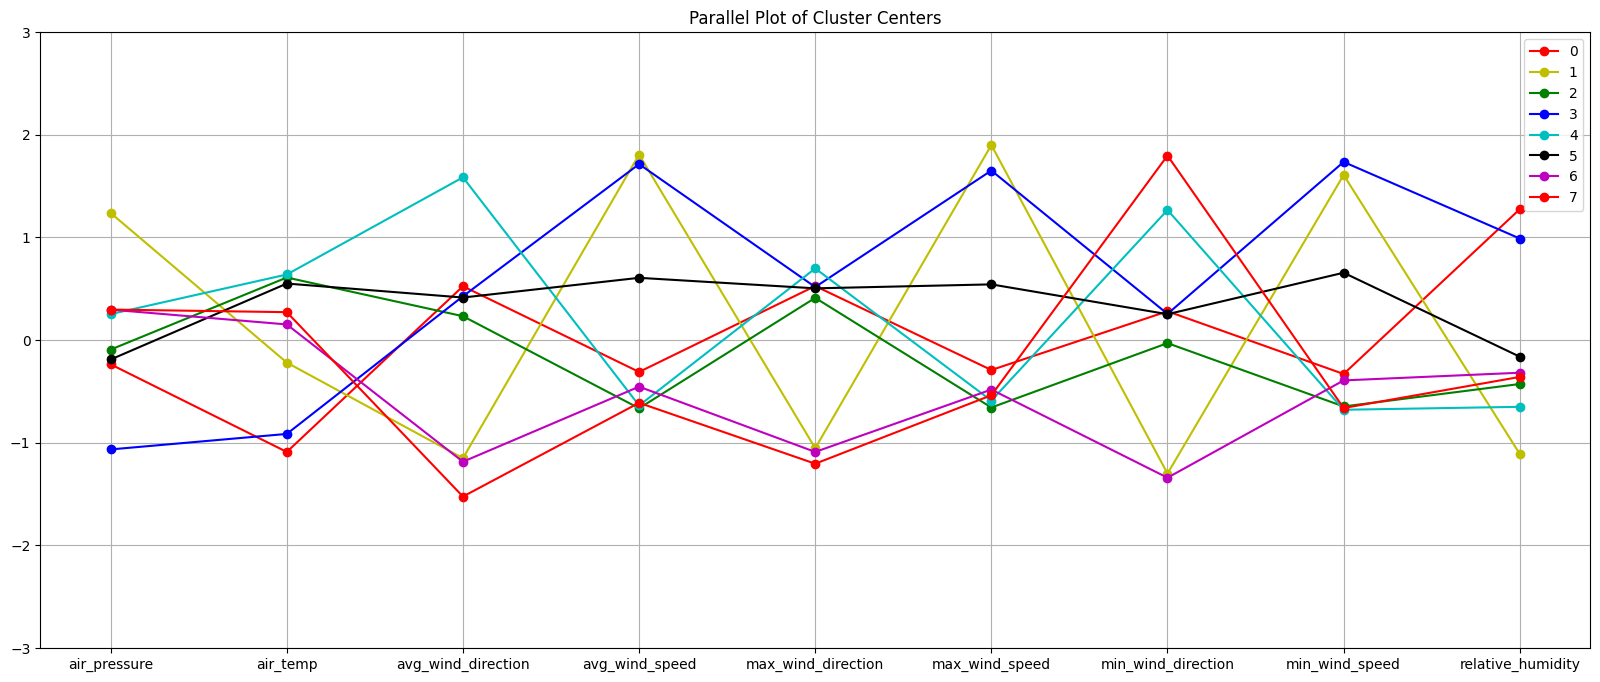

In [43]:
parallel_plot(X_train_dask.columns, 8, sklearn_kmeans)

### 2.8 Stop the Dask Client

In [44]:
# DO NOT DELETE THIS CELL
client.close() #client.shutdown()